In [1]:
import sys
import os
import matplotlib.pyplot as plt

# Add the src directory to the path. TEMPORARY FIX
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from src.data_processing.dataset_loader import CoastData

## Load the data

In [2]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SIRENA/"))

# Test with a single station. Differents stations: agrelo, cies, cadiz, samarador, arenaldentem
data = CoastData(data_path, name="snb")

# Load the data, all the different stations
data = CoastData(data_path)

CoastData: snb - 284 images
CoastData: global - 284 images


In [9]:
# Get the names of the different stations
station_names = data.get_station_names()
print(station_names)

['snb']


### Get the data from CoastData

In [3]:
image_metadata = data[0]
print(image_metadata['image']['filename'])

snb_2011_10_22_11_00.image.jpg


In [4]:
# We can get the data by station name or in a global way (only the images and the masks)
filtered_data = data.get_images() # All the data
print(filtered_data[0])

# We can also get the data by station name
filtered_data = data.get_images("snb")
print(filtered_data[0])

{'image': '/LOCALDATA/josep/code/Shoreline-extraction/data/SIRENA/images/snb_2011_10_22_11_00.image.jpg', 'mask': '/LOCALDATA/josep/code/Shoreline-extraction/data/SIRENA/masks/snb_2011_10_22_11_00.mask.png'}
{'image': '/LOCALDATA/josep/code/Shoreline-extraction/data/SIRENA/images/snb_2011_10_22_11_00.image.jpg', 'mask': '/LOCALDATA/josep/code/Shoreline-extraction/data/SIRENA/masks/snb_2011_10_22_11_00.mask.png'}


#### Plot the images and the masks

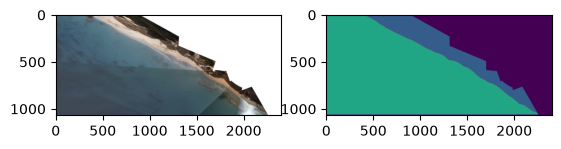

In [5]:
fig, ax = plt.subplots(1, 2)
img_path = filtered_data[0]['image']
mask_path = filtered_data[0]['mask']

ax[0].imshow(plt.imread(img_path))
ax[1].imshow(plt.imread(mask_path))

plt.show()

## Split data

In [6]:
data_splits = data.split_data(val_size = 0.2, test_size = 0.1)

print("\nTrain size: ", len(data_splits["train"]['images']))
print("Validation size: ", len(data_splits["validation"]['images']))
print("Test size: ", len(data_splits["test"]['images']))

Coast: snb, Total size: 284

Train size:  198
Validation size:  57
Test size:  29
